# **UGST4158 — Introduction to Public Policy 2025/26 Winter**
# Central European University
## Time Series Analysis on Air Quality of Milan

Quantitative Methods Seminar
- Liza Drini
- Benedek Szalma
- Zeteny Cseresznyes  

### 0. Modules

In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore

### 1. Data Loading

In [2]:
df = pd.read_csv('../Data/milan_air_quality.csv')
df.head()

,time_stamp,sensor_index,humidity,temperature,pressure,pm2.5_atm,pm2.5_atm_a,pm2.5_atm_b,pm10.0_atm
0,1741996800,264579,37.0,76.0,988.45,9.9,9.1,10.8,10.8
1,1742083200,264579,37.0,67.0,993.94,9.6,9.1,10.1,11.2
2,1742169600,264579,42.0,60.0,998.66,21.3,20.3,22.2,23.6
3,1742256000,264579,40.0,53.0,1010.44,16.5,16.1,17.0,18.2
4,1742342400,264579,36.0,55.0,1013.30,39.1,38.8,39.5,46.2


### 2. Data Preprocessing

#### 2.1. Data Types

In [3]:
df.dtypes

time_stamp        int64
sensor_index      int64
humidity        float64
temperature     float64
pressure        float64
pm2.5_atm       float64
pm2.5_atm_a     float64
pm2.5_atm_b     float64
pm10.0_atm      float64
dtype: object

#### 2.2. Timestamp Conversion

In [4]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='s')
df['time_stamp'] = df['time_stamp'].dt.strftime('%Y-%m-%d')
df['time_stamp']

0       2025-03-15
1       2025-03-16
2       2025-03-17
3       2025-03-18
4       2025-03-19
           ...    
4314    2025-12-26
4315    2025-12-27
4316    2025-12-28
4317    2025-12-29
4318    2025-12-30
Name: time_stamp, Length: 4319, dtype: str

#### 2.3. Set Index and Sort

In [5]:
df = df.set_index('time_stamp')
df = df.sort_index()

#### 2.4. Missing Values

In [6]:
df.isna().sum()

sensor_index     0
humidity        23
temperature     23
pressure        23
pm2.5_atm        0
pm2.5_atm_a      0
pm2.5_atm_b      0
pm10.0_atm       0
dtype: int64

### 3. Pivot Table

#### 3.1. Build Pivot

In [7]:
import numpy as np

features = [
    'humidity', 'temperature', 'pressure',
    'pm2.5_atm', 'pm2.5_atm_a', 'pm2.5_atm_b',
    'pm10.0_atm'
]

tensor = df.pivot_table(
    index='time_stamp',
    columns='sensor_index',
    values=features
)

tensor_array = tensor.values

#### 3.2. Inspect Tensor Array

In [8]:
tensor_array

array([[52., 63., nan, ..., nan, nan, nan],
       [55., 65., nan, ..., nan, nan, nan],
       [59., 68., nan, ..., nan, nan, nan],
       ...,
       [45., 59., 49., ..., 51., 57., 49.],
       [45., 57., 49., ..., 50., 56., 47.],
       [50., 66., 54., ..., 47., 52., 46.]], shape=(1413, 49))

### 4. Time Series Plots

#### 4.1. PM2.5 and PM10 Over Time

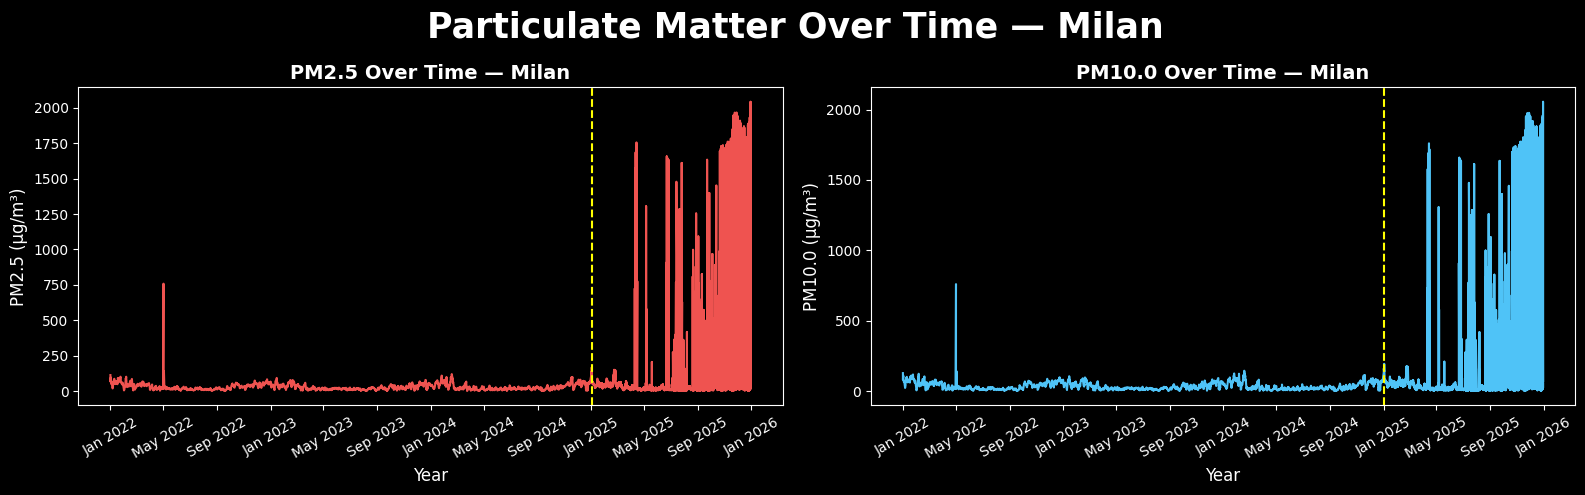

In [9]:
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_atm'], color='#66bb6a', linewidth=1.5)
    axes[0].set_title("PM2.5 Over Time — Milan", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Year", fontsize=12)
    axes[0].set_ylabel("PM2.5 (µg/m³)", fontsize=12)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].tick_params(axis='x', rotation=30, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[0].grid(False)

    axes[1].plot(pd.to_datetime(df.index), df['pm10.0_atm'], color='#87ceeb', linewidth=1.5)
    axes[1].set_title("PM10.0 Over Time — Milan", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Year", fontsize=12)
    axes[1].set_ylabel("PM10.0 (µg/m³)", fontsize=12)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=30, labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[1].grid(False)

    fig.suptitle("Particulate Matter Over Time — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/particulate_matter_over_time_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 4.2. PM2.5 and PM10 — 7-Day Rolling Average

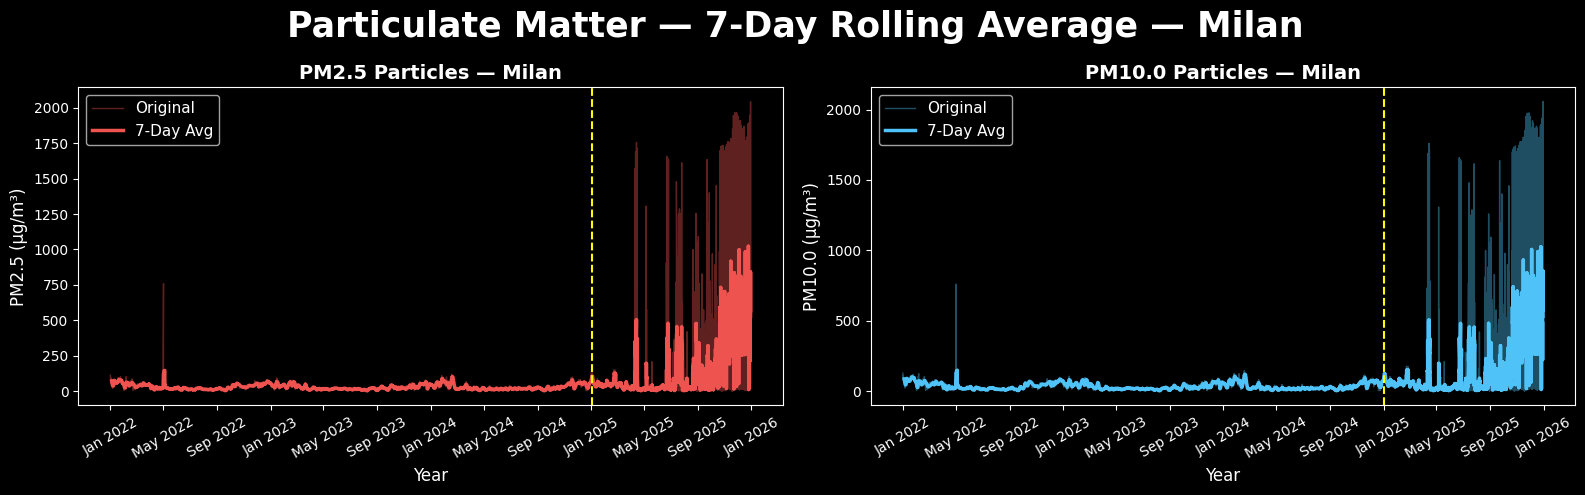

In [10]:
df['pm2.5_7day_avg'] = df['pm2.5_atm'].rolling(window=7).mean()
df['pm10_7day_avg'] = df['pm10.0_atm'].rolling(window=7).mean()

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_atm'], alpha=0.4, color='#66bb6a', label='Original', linewidth=1)
    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_7day_avg'], color='#66bb6a', label='7-Day Avg', linewidth=2.5)
    axes[0].set_title("PM2.5 Particles — Milan", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Year", fontsize=12)
    axes[0].set_ylabel("PM2.5 (µg/m³)", fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].tick_params(axis='x', rotation=30, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[0].grid(False)

    axes[1].plot(pd.to_datetime(df.index), df['pm10.0_atm'], alpha=0.4, color='#87ceeb', label='Original', linewidth=1)
    axes[1].plot(pd.to_datetime(df.index), df['pm10_7day_avg'], color='#87ceeb', label='7-Day Avg', linewidth=2.5)
    axes[1].set_title("PM10.0 Particles — Milan", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Year", fontsize=12)
    axes[1].set_ylabel("PM10.0 (µg/m³)", fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=30, labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[1].grid(False)

    fig.suptitle("Particulate Matter — 7-Day Rolling Average — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/particulate_matter_7_day_rolling_average_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Sensor Analysis

#### 5.1. Unique Sensors

In [11]:
df['sensor_index'].unique()

array([  6540,  31569, 188049, 188041, 188043, 256425, 264579])

#### 5.2. Feature Scatter Plots by Sensor

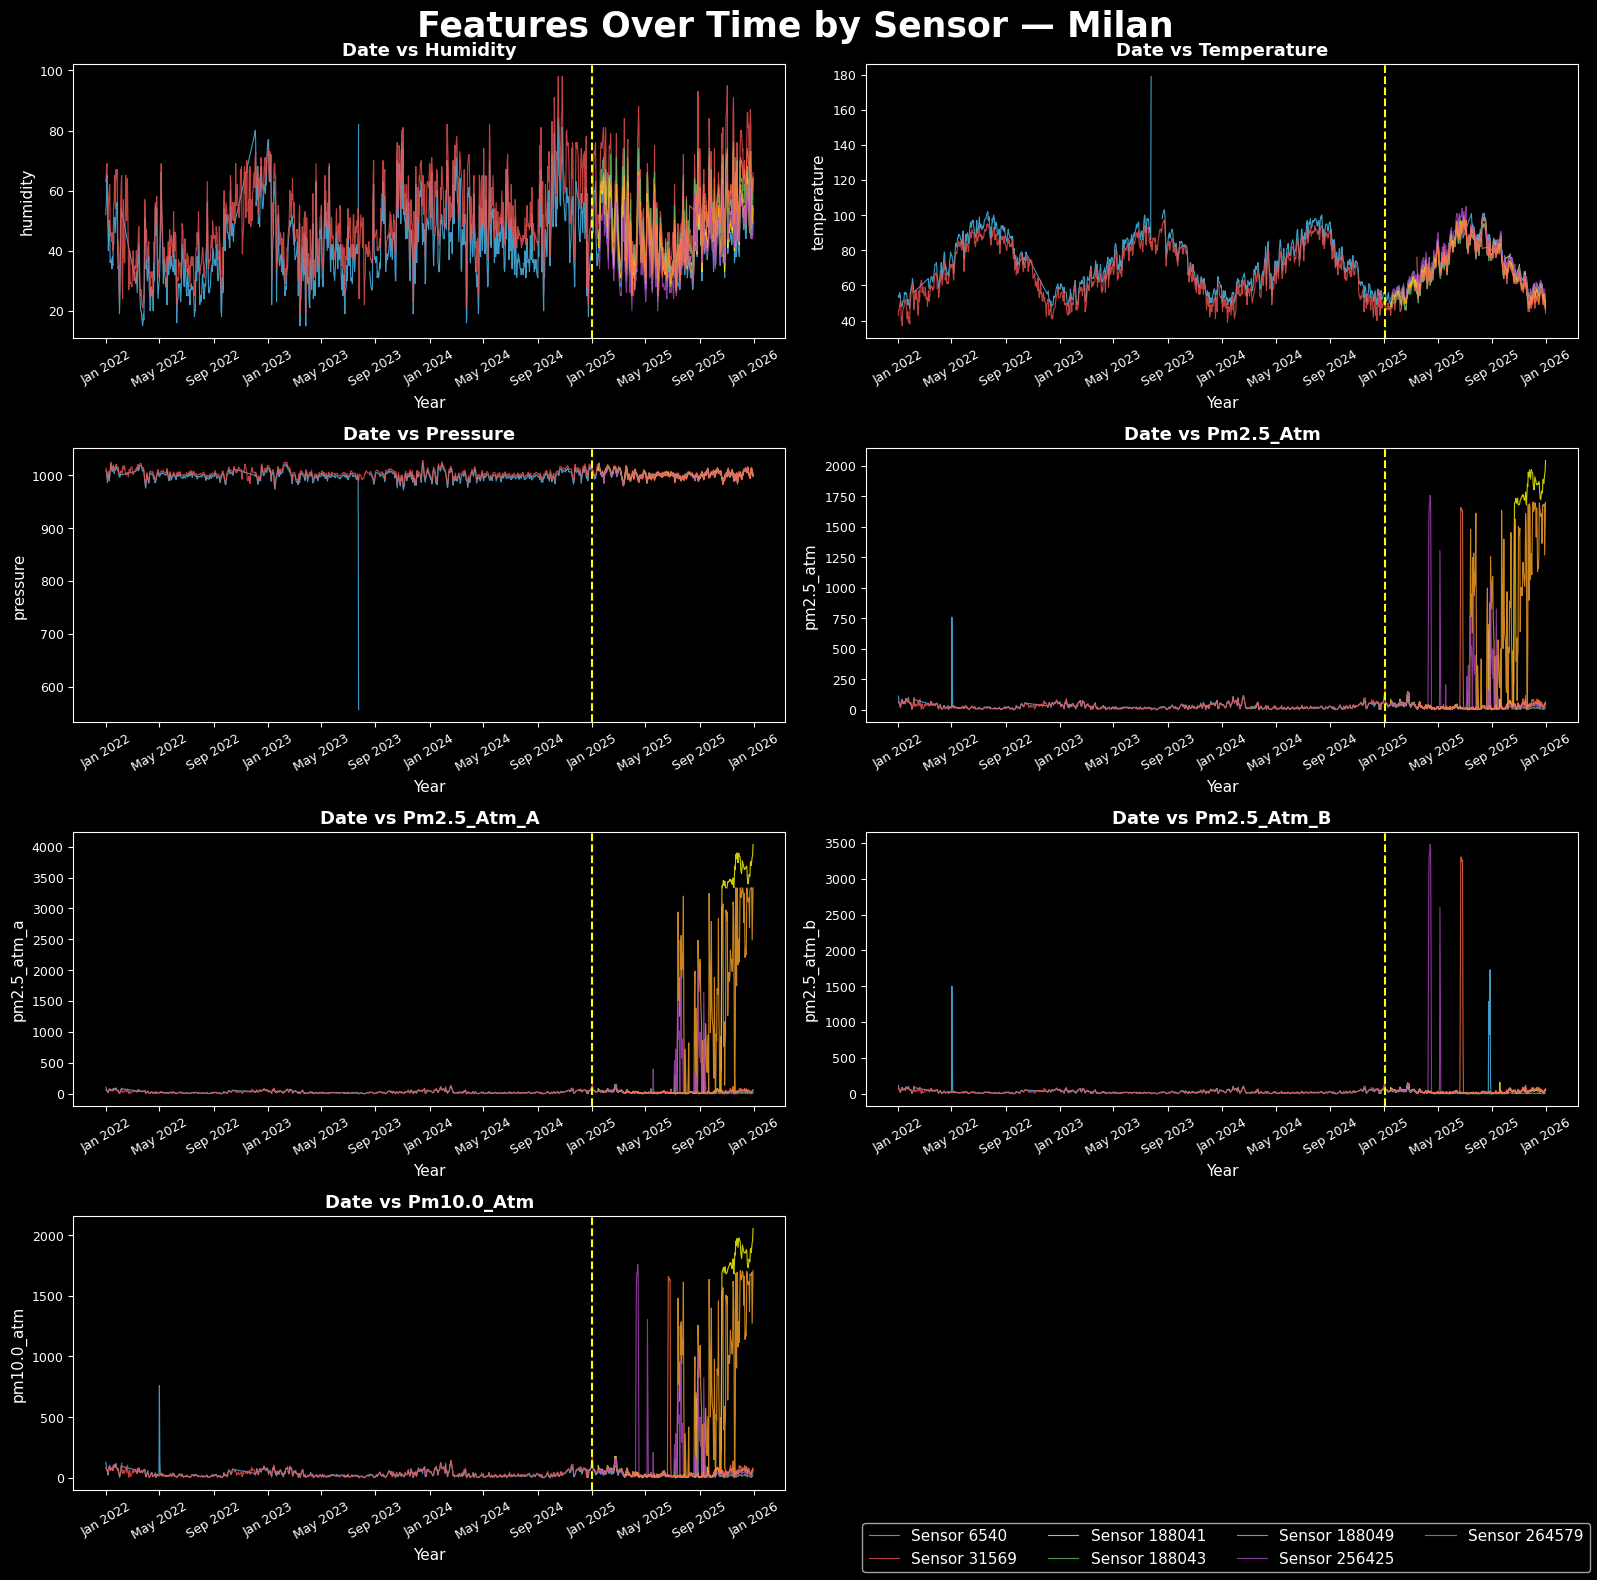

In [12]:
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 2, figsize=(16, 16))
    axes = axes.flatten()

    sensor_list = sorted(df['sensor_index'].unique())
    sensor_colors = ['#87ceeb', '#66bb6a', 'yellow', '#66bb6a', '#ffa726', '#ab47bc', '#ff7043']

    for ax, col in zip(axes, features):
        for sensor, color in zip(sensor_list, sensor_colors):
            group = df[df['sensor_index'] == sensor]
            ax.plot(pd.to_datetime(group.index), group[col], color=color,
                label=f'Sensor {sensor}', linewidth=0.8, alpha=0.8)
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        ax.set_title(f'Date vs {col.title()}', fontsize=13, fontweight='bold')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        ax.grid(False)

    axes[-1].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', fontsize=11, ncol=4)
    fig.suptitle("Features Over Time by Sensor — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/features_over_time_by_sensor_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.3. PM2.5 and PM10 per Sensor

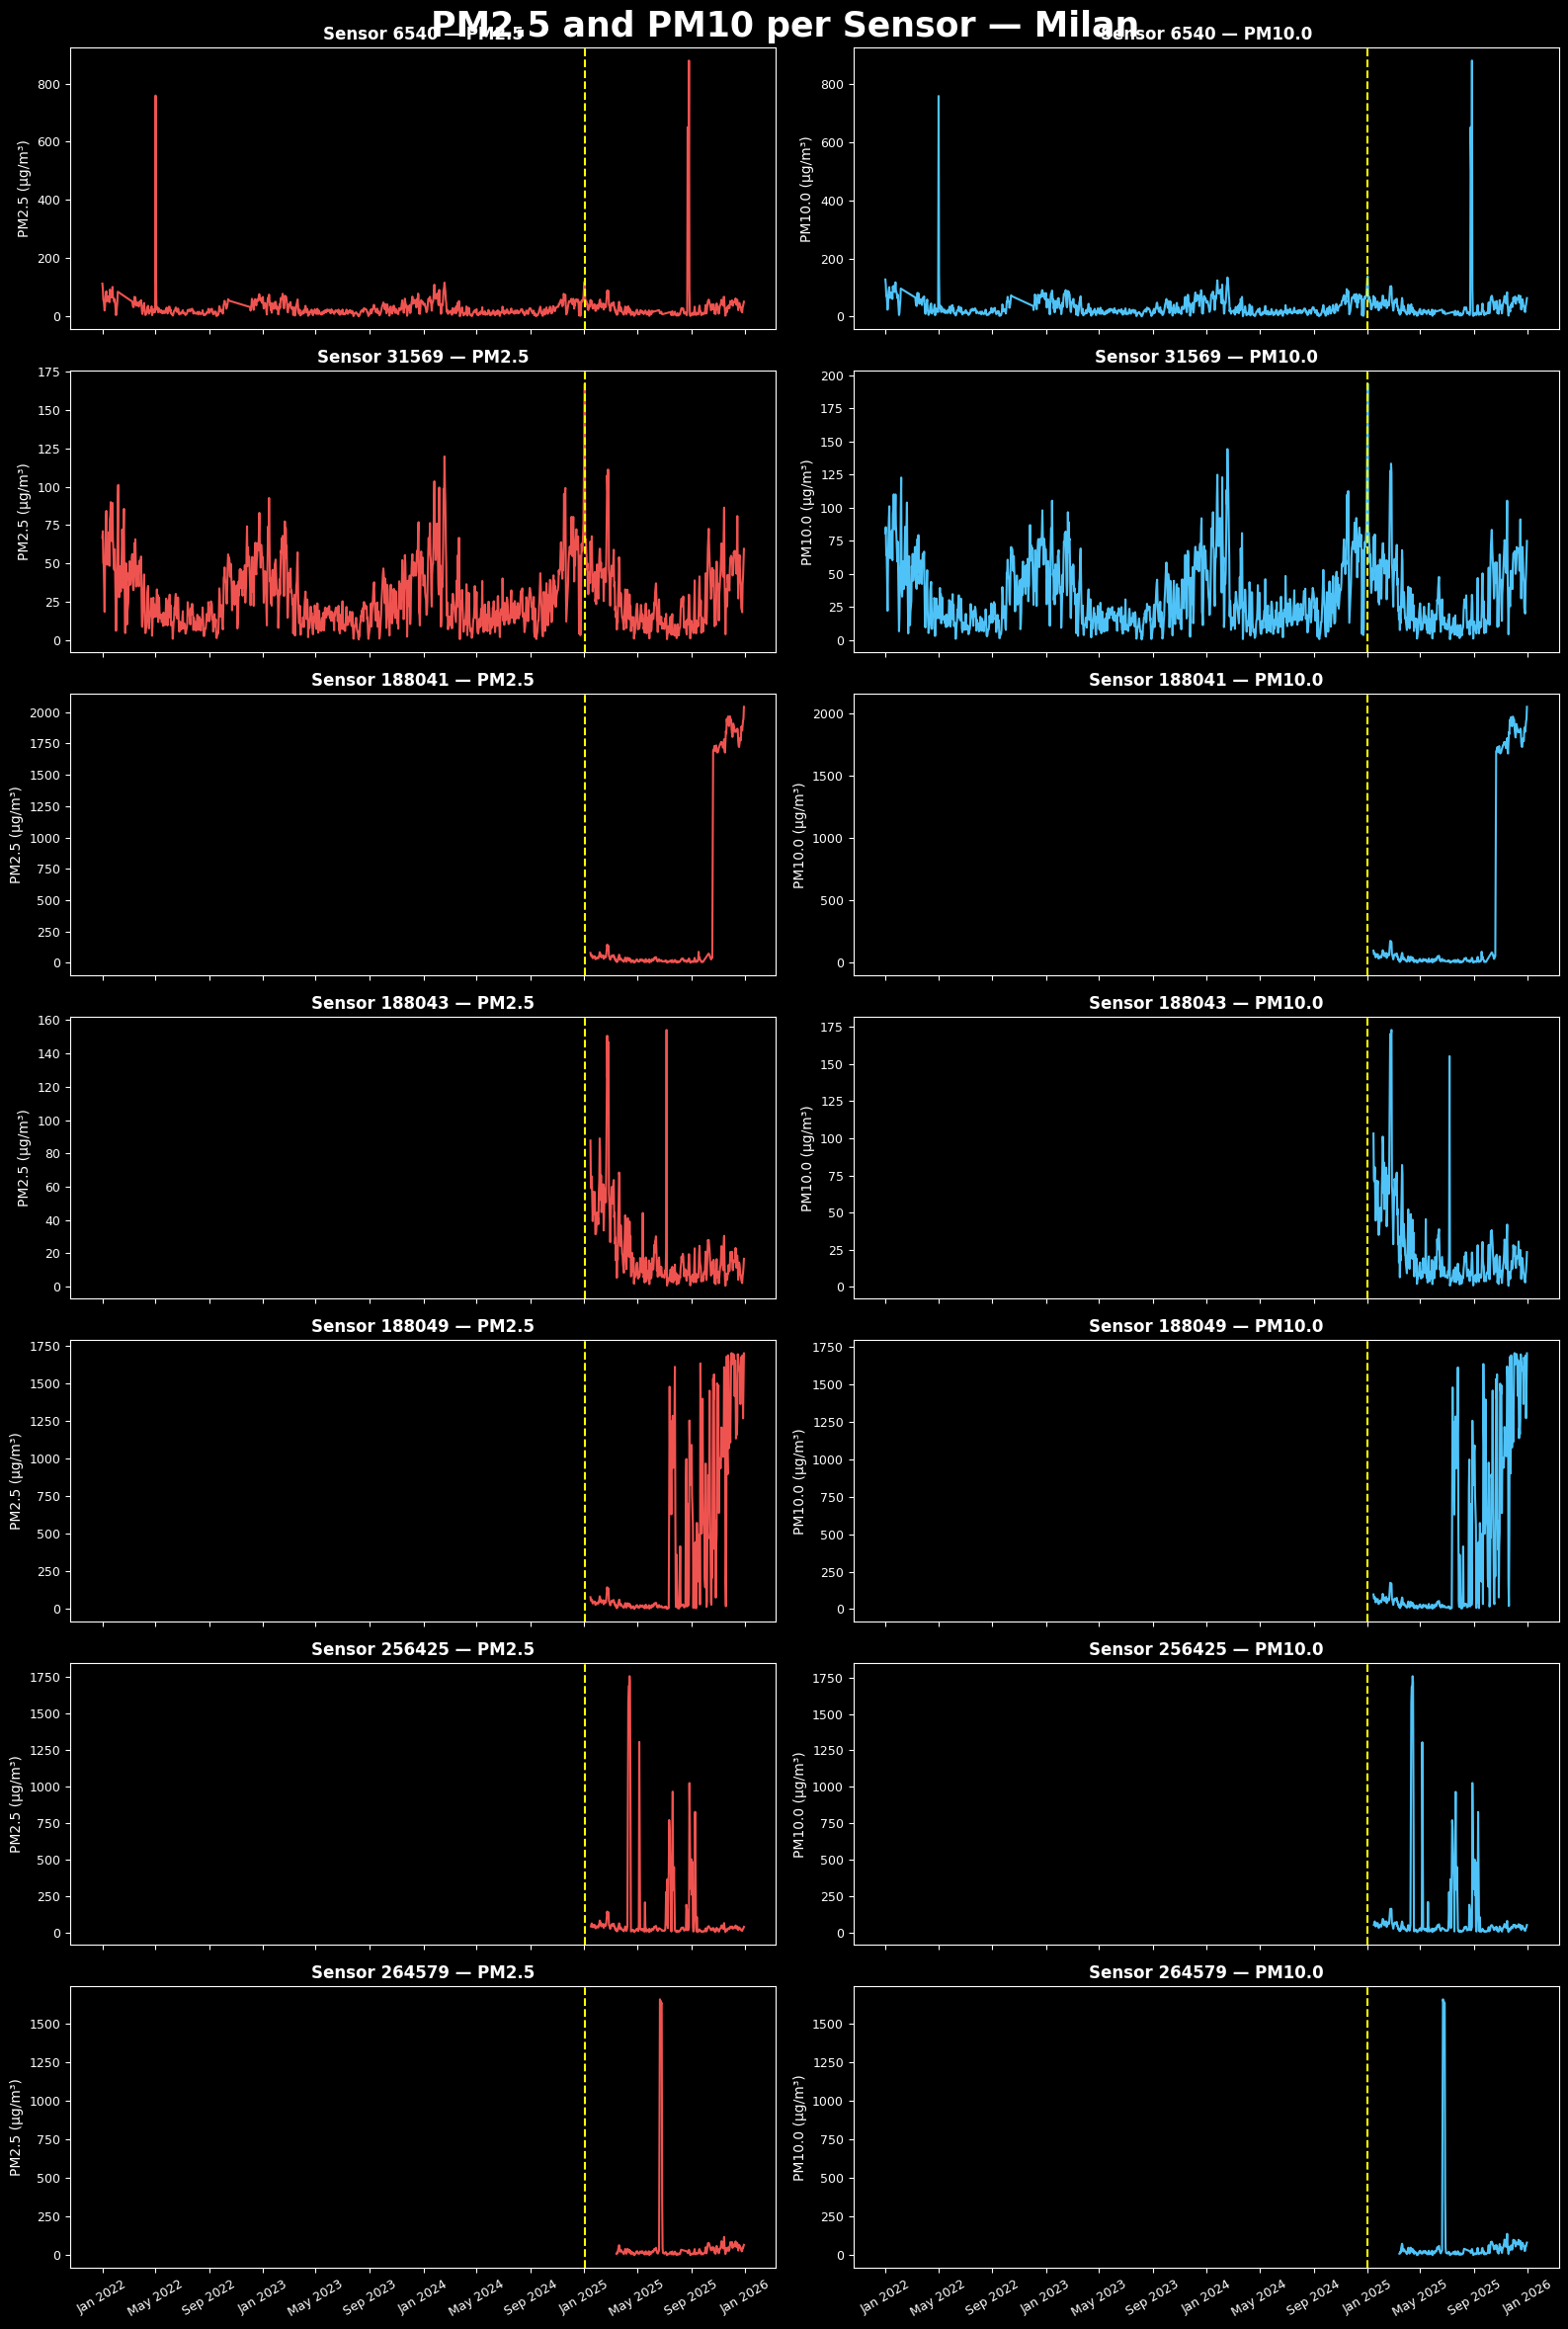

In [13]:
sensors = sorted(df['sensor_index'].unique())

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(len(sensors), 2, figsize=(16, 24), sharex=True)

    for i, sensor in enumerate(sensors):
        df_sensor = df[df['sensor_index'] == sensor]

        axes[i, 0].plot(pd.to_datetime(df_sensor.index), df_sensor['pm2.5_atm'], color='#66bb6a', linewidth=1.5)
        axes[i, 0].set_title(f'Sensor {sensor} — PM2.5', fontsize=12, fontweight='bold')
        axes[i, 0].set_ylabel('PM2.5 (µg/m³)', fontsize=10)
        axes[i, 0].tick_params(axis='y', labelsize=9)
        axes[i, 0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 0].grid(False)

        axes[i, 1].plot(pd.to_datetime(df_sensor.index), df_sensor['pm10.0_atm'], color='#87ceeb', linewidth=1.5)
        axes[i, 1].set_title(f'Sensor {sensor} — PM10.0', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('PM10.0 (µg/m³)', fontsize=10)
        axes[i, 1].tick_params(axis='y', labelsize=9)
        axes[i, 1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 1].grid(False)

    # set locator/formatter once — sharex means all axes share it
    axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # show x-axis labels only on the bottom row
    for ax in axes[-1]:
        ax.tick_params(axis='x', rotation=30, labelsize=9)

    fig.suptitle("PM2.5 and PM10 per Sensor — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/pm2_5_and_pm10_per_sensor_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.4. Z-Score Anomaly Detection

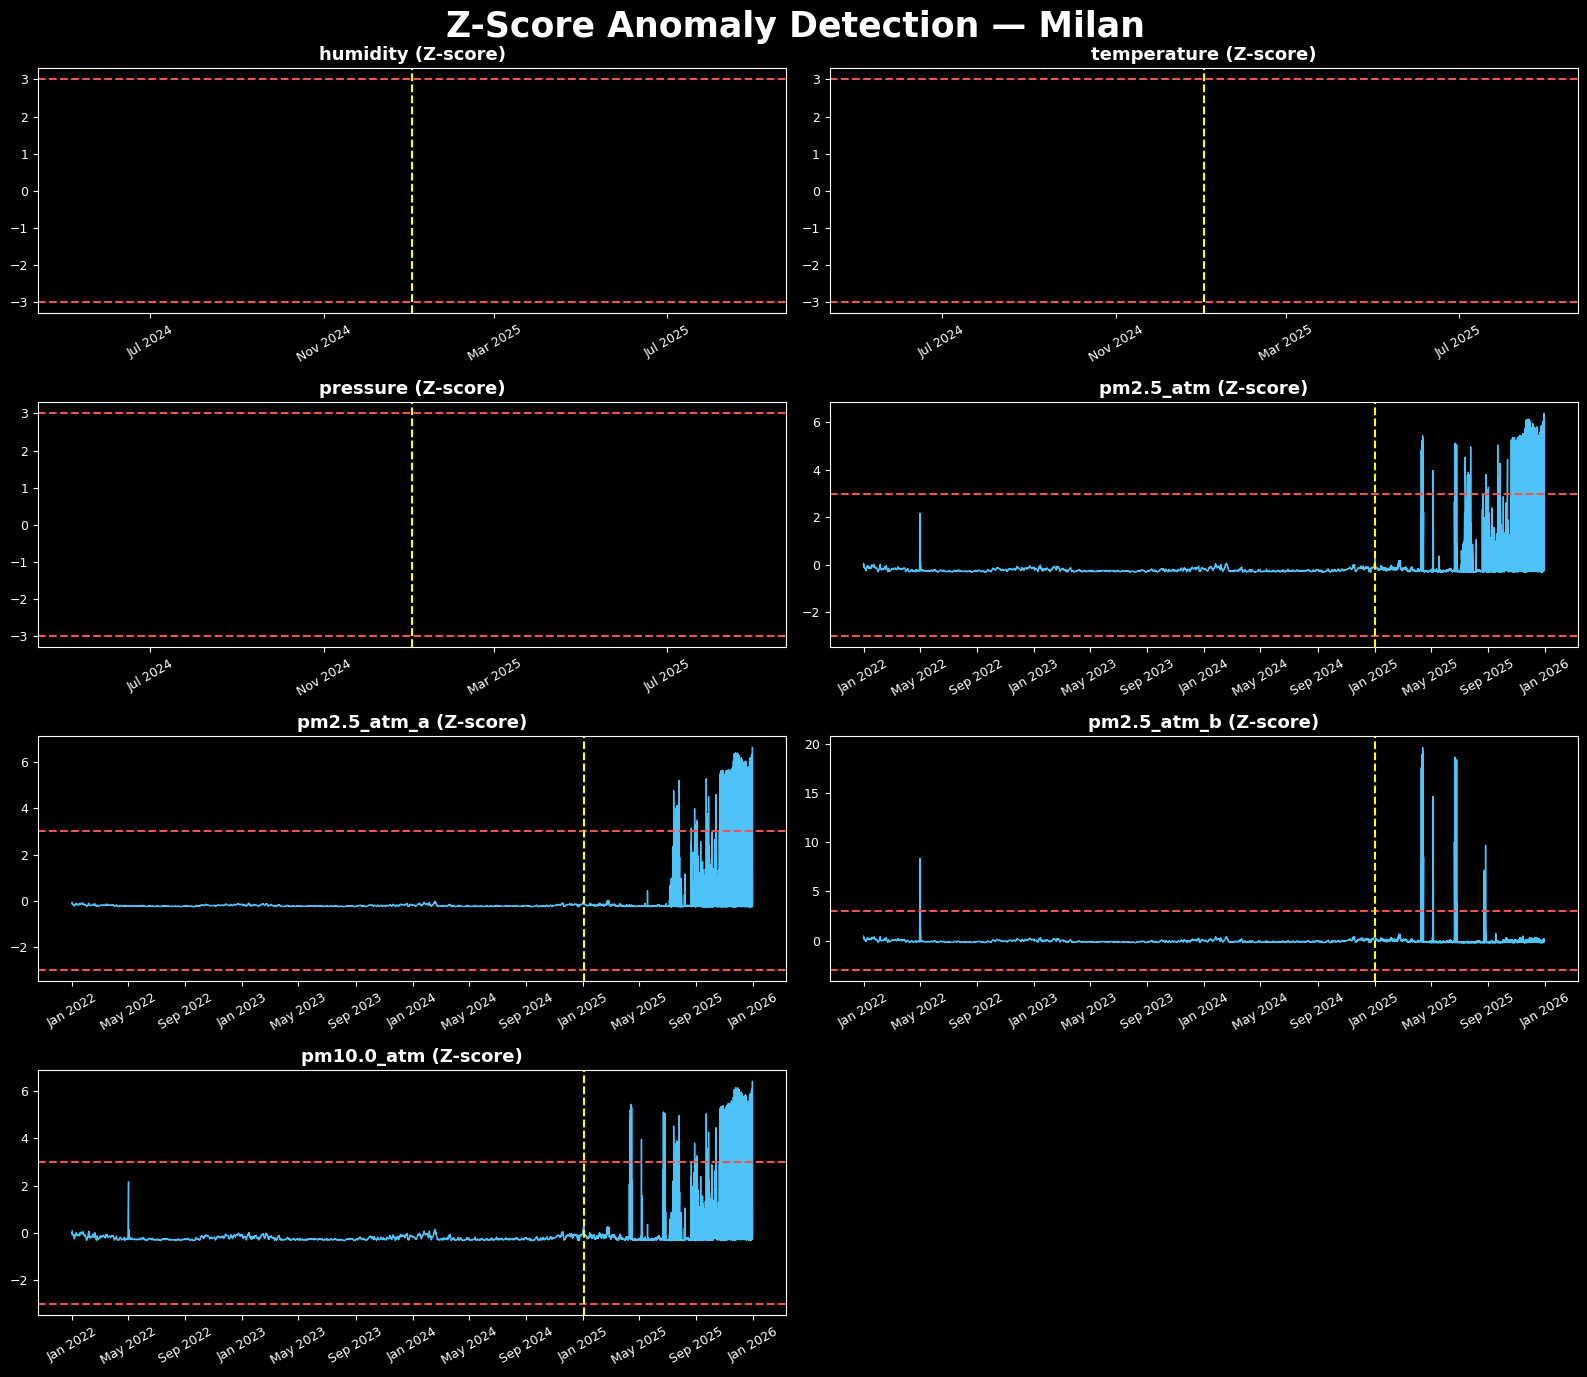

In [14]:
df = df.reset_index()
df_z = df.copy()
df_z[features] = df[features].apply(zscore)

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    axes = axes.flatten()

    for ax, col in zip(axes, features):
        ax.plot(pd.to_datetime(df['time_stamp']), df_z[col], color='#87ceeb', linewidth=1)
        ax.axhline(3, color='#66bb6a', linestyle='--', linewidth=1.5)
        ax.axhline(-3, color='#66bb6a', linestyle='--', linewidth=1.5)
        ax.set_title(f'{col} (Z-score)', fontsize=13, fontweight='bold')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        ax.grid(False)

    axes[-1].set_visible(False)
    fig.suptitle("Z-Score Anomaly Detection — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/z_score_anomaly_detection_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.5. Outlier Treatment

Outlier counts per feature (outside good-sensor ±3σ range):
humidity         7
temperature      1
pressure         1
pm2.5_atm      270
pm2.5_atm_a    303
pm2.5_atm_b     22
pm10.0_atm     272
Name: count, dtype: int64

Total outlier values : 876
Rows with ≥1 outlier : 333


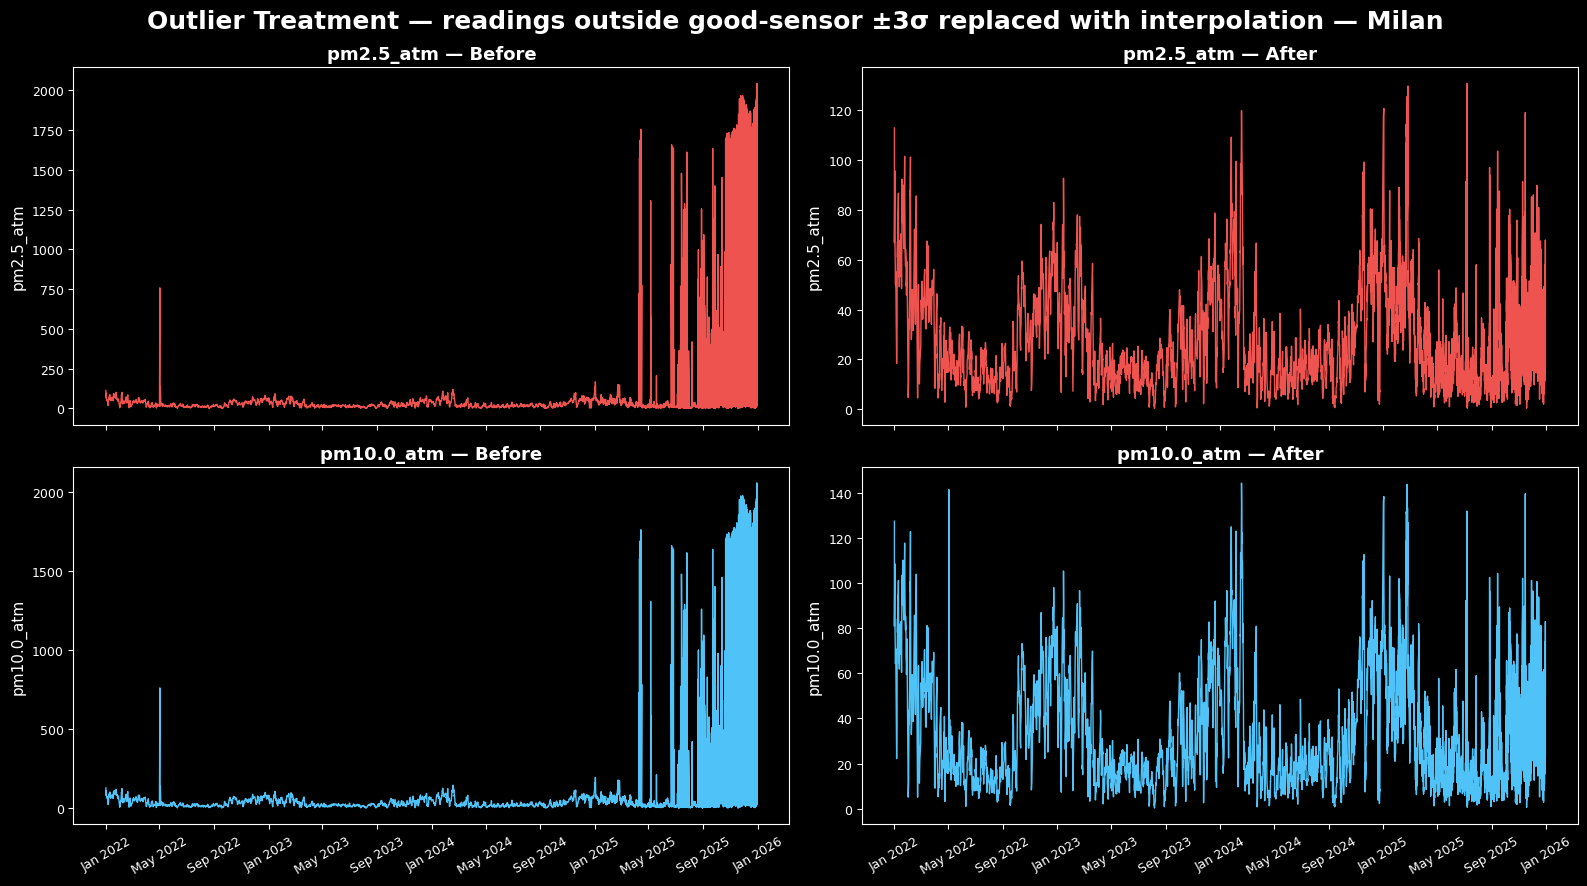

In [15]:
GOOD_SENSORS = [6540, 31569]

# compute mean and std from the two functioning sensors only
df_ref = df[df['sensor_index'].isin(GOOD_SENSORS)]
ref_mean = df_ref[features].mean()
ref_std  = df_ref[features].std()

# flag readings outside mean ± 3*std of the good sensors
df_clean = df.copy()
outlier_mask = pd.DataFrame(False, index=df.index, columns=features)
for col in features:
    lo = ref_mean[col] - 3 * ref_std[col]
    hi = ref_mean[col] + 3 * ref_std[col]
    outlier_mask[col] = (df[col] < lo) | (df[col] > hi)

print("Outlier counts per feature (outside good-sensor ±3σ range):")
print(outlier_mask.sum().rename("count"))
print(f"\nTotal outlier values : {outlier_mask.sum().sum()}")
print(f"Rows with ≥1 outlier : {outlier_mask.any(axis=1).sum()}")

# replace outliers with NaN, then linearly interpolate
for col in features:
    df_clean.loc[outlier_mask[col], col] = np.nan
df_clean[features] = df_clean[features].interpolate(method='linear')

# before / after plot for PM2.5 and PM10
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

    for row, (col, color) in enumerate(zip(['pm2.5_atm', 'pm10.0_atm'], ['#66bb6a', '#87ceeb'])):
        axes[row, 0].plot(pd.to_datetime(df['time_stamp']), df[col], color=color, linewidth=1)
        axes[row, 0].set_title(f'{col} — Before', fontsize=13, fontweight='bold')
        axes[row, 0].set_ylabel(col, fontsize=11)
        axes[row, 0].tick_params(axis='y', labelsize=9)
        axes[row, 0].grid(False)

        axes[row, 1].plot(pd.to_datetime(df_clean['time_stamp']), df_clean[col], color=color, linewidth=1)
        axes[row, 1].set_title(f'{col} — After', fontsize=13, fontweight='bold')
        axes[row, 1].set_ylabel(col, fontsize=11)
        axes[row, 1].tick_params(axis='y', labelsize=9)
        axes[row, 1].grid(False)

    axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    for ax in axes[-1]:
        ax.tick_params(axis='x', rotation=30, labelsize=9)

    fig.suptitle("Outlier Treatment — readings outside good-sensor ±3σ replaced with interpolation — Milan",
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Figures/outlier_treatment_readings_outside_good_sensor_3_replaced_with_interpolation_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Time Series Analysis

#### 6.1. Aggregate and Set Frequency

In [16]:
# average cleaned readings across sensors per day → single daily time series
df_ts = df_clean.copy()
df_ts['time_stamp'] = pd.to_datetime(df_ts['time_stamp'])
df_ts = df_ts.groupby('time_stamp')[features].mean()
df_ts = df_ts.asfreq('D')

#### 6.2. PM2.5 Overview

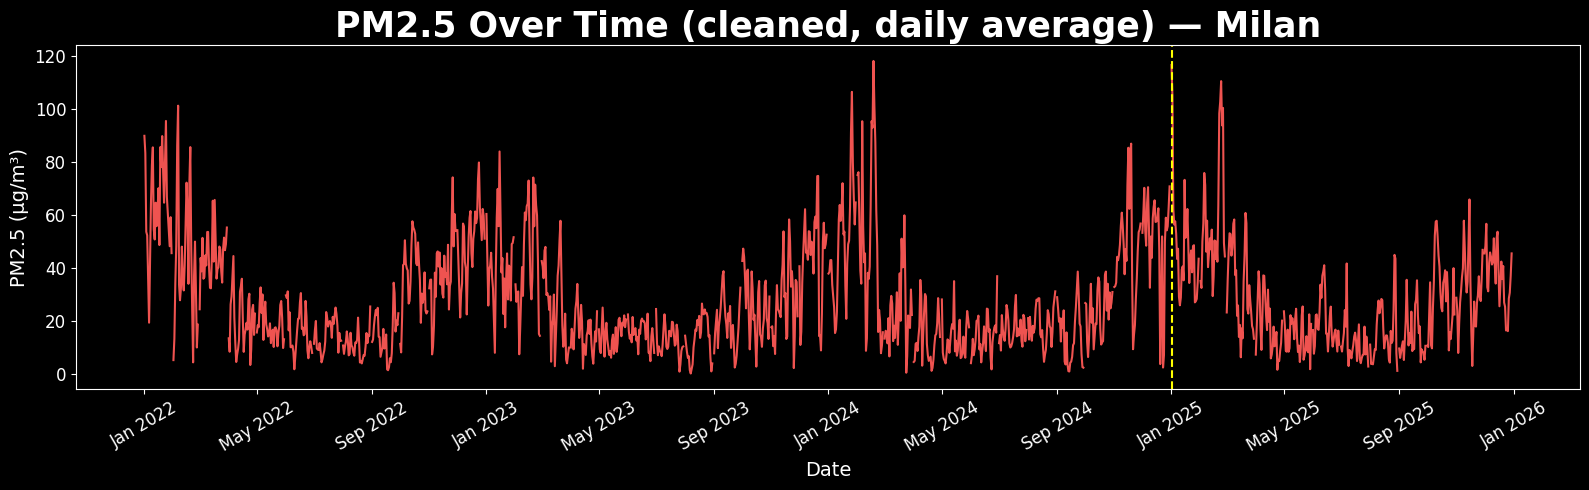

In [17]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_ts.index, df_ts['pm2.5_atm'], color='#66bb6a', linewidth=1.5)
    ax.set_title('PM2.5 Over Time (cleaned, daily average) — Milan', fontsize=25, fontweight="bold")
    ax.set_xlabel("Date", fontsize=14)
    ax.set_ylabel("PM2.5 (µg/m³)", fontsize=14)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm2_5_over_time_cleaned_daily_average_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 6.3. Stationarity Test (ADF)

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_ts['pm2.5_atm'].dropna())
print("PM2.5 ADF p-value:", result[1])
result = adfuller(df_ts['pm10.0_atm'].dropna())
print("PM10 ADF p-value:", result[1])

PM2.5 ADF p-value: 0.00023441712627159943
PM10 ADF p-value: 0.00038858940628325585


#### 6.4. Seasonal Decomposition — PM2.5 and PM10

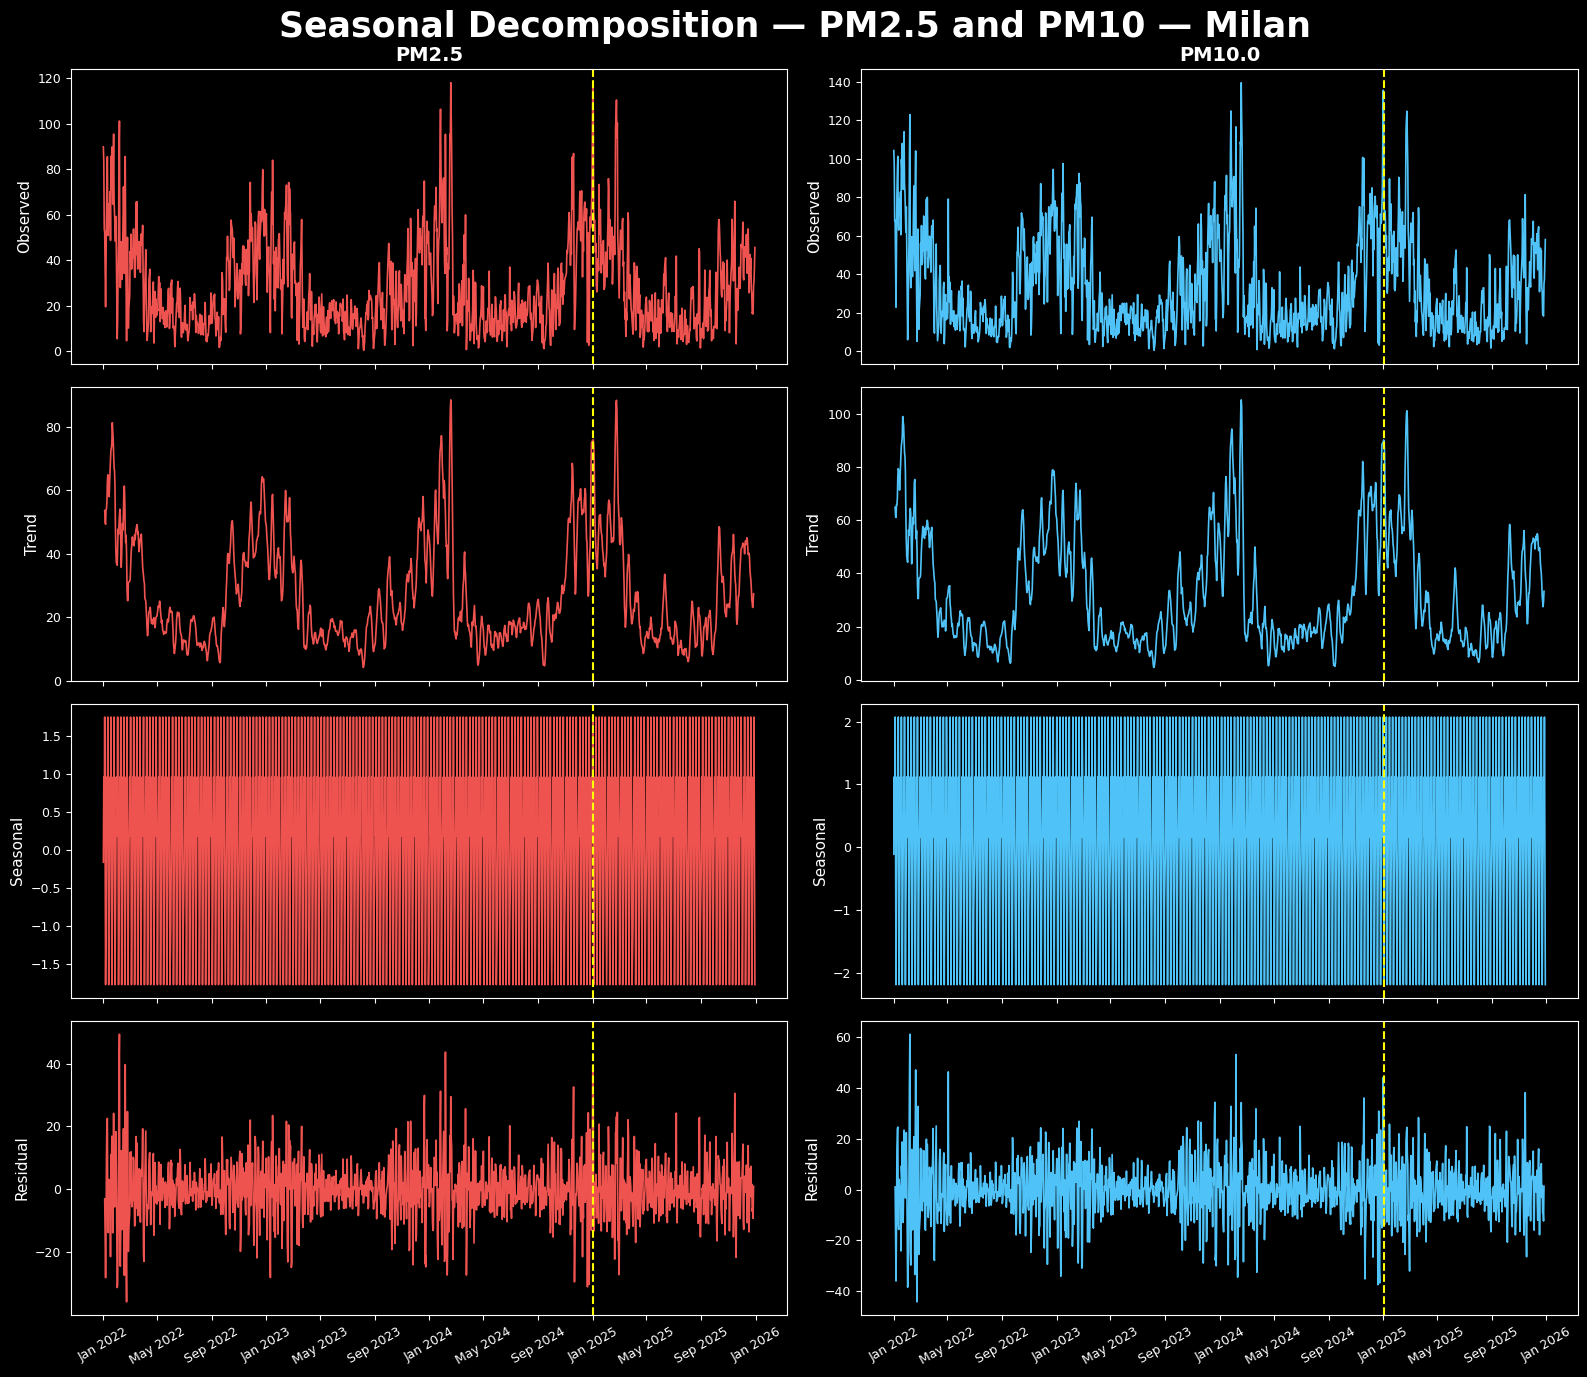

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

result  = seasonal_decompose(df_ts['pm2.5_atm'].dropna(),  model='additive', period=7)
result2 = seasonal_decompose(df_ts['pm10.0_atm'].dropna(), model='additive', period=7)

components = [
    (result.observed, result2.observed, 'Observed'),
    (result.trend,    result2.trend,    'Trend'),
    (result.seasonal, result2.seasonal, 'Seasonal'),
    (result.resid,    result2.resid,    'Residual'),
]

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

    for i, (pm25_comp, pm10_comp, label) in enumerate(components):
        axes[i, 0].plot(pd.to_datetime(pm25_comp.index), pm25_comp, color='#66bb6a', linewidth=1.2)
        axes[i, 0].set_ylabel(label, fontsize=11)
        axes[i, 0].tick_params(axis='y', labelsize=9)
        axes[i, 0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 0].grid(False)

        axes[i, 1].plot(pd.to_datetime(pm10_comp.index), pm10_comp, color='#87ceeb', linewidth=1.2)
        axes[i, 1].set_ylabel(label, fontsize=11)
        axes[i, 1].tick_params(axis='y', labelsize=9)
        axes[i, 1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 1].grid(False)

    axes[0, 0].set_title("PM2.5", fontsize=14, fontweight="bold")
    axes[0, 1].set_title("PM10.0", fontsize=14, fontweight="bold")

    axes[-1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    for ax in axes[-1]:
        ax.tick_params(axis='x', rotation=30, labelsize=9)

    fig.suptitle("Seasonal Decomposition — PM2.5 and PM10 — Milan", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/seasonal_decomposition_pm2_5_and_pm10_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 6.5. Correlation with Environmental Factors — PM2.5

In [20]:
df_ts[['pm2.5_atm', 'temperature', 'humidity']].corr()

,pm2.5_atm,temperature,humidity
pm2.5_atm,1.000000,-0.576491,0.327517
temperature,-0.576491,1.000000,-0.449929
humidity,0.327517,-0.449929,1.000000


#### 6.6. Correlation with Environmental Factors — PM10

In [21]:
df_ts[['pm10.0_atm', 'temperature', 'humidity']].corr()

,pm10.0_atm,temperature,humidity
pm10.0_atm,1.000000,-0.594967,0.332760
temperature,-0.594967,1.000000,-0.449929
humidity,0.332760,-0.449929,1.000000


### 7. Time Series Forecasting (SARIMAX)

#### 7.1. PM2.5 SARIMAX Forecast

c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

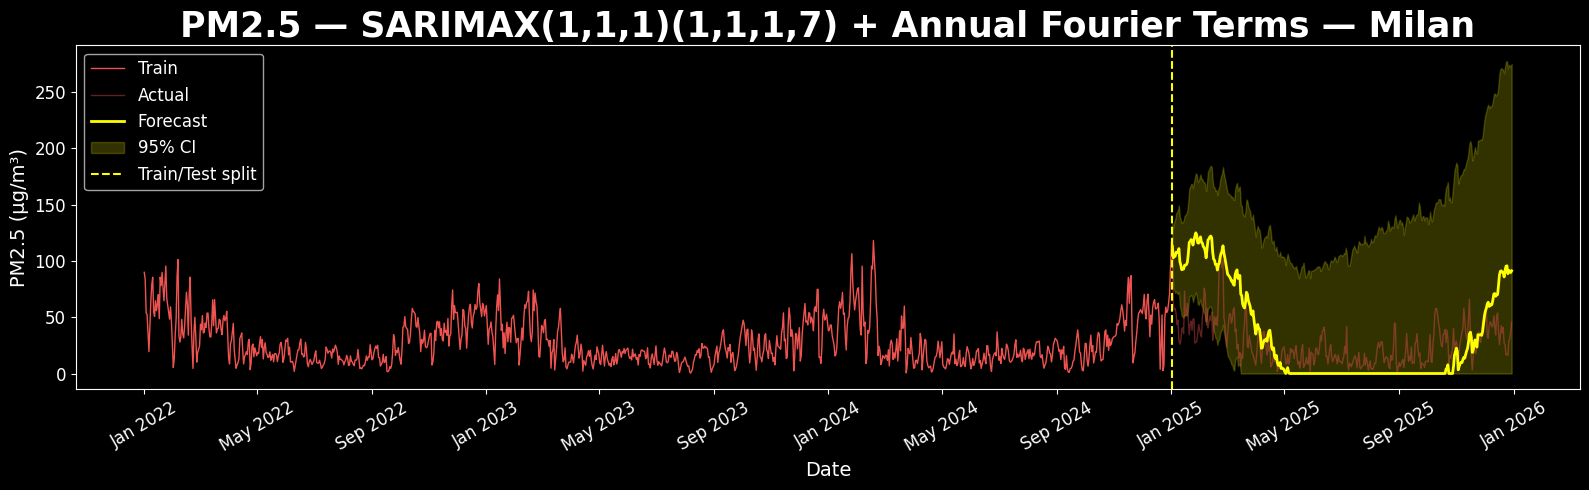

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SPLIT = pd.Timestamp('2025-01-02')

# Fourier terms for annual seasonality (K pairs of sin/cos at yearly frequency)
def fourier_terms(index, period=365.25, K=3):
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

fourier = fourier_terms(df_ts.index)
exog_cols = ['temperature', 'humidity']

pm25_series = df_ts['pm2.5_atm'].dropna()
exog_all    = df_ts[exog_cols].join(fourier).reindex(pm25_series.index).interpolate()

pm25_train = pm25_series[pm25_series.index < SPLIT]
pm25_test  = pm25_series[pm25_series.index >= SPLIT]
exog_train = exog_all[exog_all.index < SPLIT]
exog_test  = exog_all[exog_all.index >= SPLIT]

model_fit_pm25 = SARIMAX(
    pm25_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
).fit(disp=False)

fc = model_fit_pm25.get_forecast(steps=len(pm25_test), exog=exog_test)
fc_mean = fc.predicted_mean.clip(lower=0)   # PM2.5 cannot be negative
fc_ci   = fc.conf_int().clip(lower=0)
fc_mean.index = pm25_test.index
fc_ci.index   = pm25_test.index

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(pm25_train.index, pm25_train, color='#66bb6a', linewidth=1,         label='Train')
    ax.plot(pm25_test.index,  pm25_test,  color='#66bb6a', linewidth=1, alpha=0.4, label='Actual')
    ax.plot(fc_mean.index,    fc_mean,    color='yellow',  linewidth=2,         label='Forecast')
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                    color='yellow', alpha=0.2, label='95% CI')
    ax.axvline(SPLIT, color='yellow', linestyle='--', linewidth=1.5, label='Train/Test split')

    ax.set_title('PM2.5 — SARIMAX(1,1,1)(1,1,1,7) + Annual Fourier Terms — Milan', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=14)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm2_5_sarimax_1_1_1_1_1_1_7_annual_fourier_terms_milan.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 7.2. PM10 SARIMAX Forecast

c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

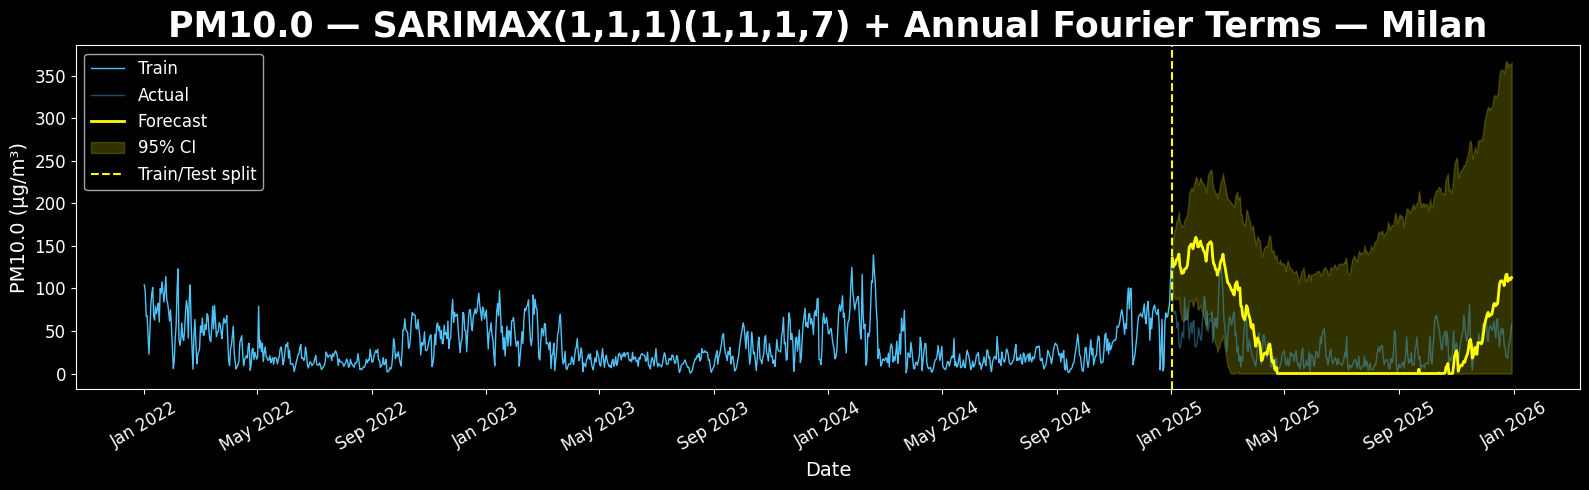

In [23]:
pm10_series = df_ts['pm10.0_atm'].dropna()
exog_all    = df_ts[exog_cols].join(fourier).reindex(pm10_series.index).interpolate()

pm10_train = pm10_series[pm10_series.index < SPLIT]
pm10_test  = pm10_series[pm10_series.index >= SPLIT]
exog_train = exog_all[exog_all.index < SPLIT]
exog_test  = exog_all[exog_all.index >= SPLIT]

model_fit_pm10 = SARIMAX(
    pm10_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
).fit(disp=False)

fc = model_fit_pm10.get_forecast(steps=len(pm10_test), exog=exog_test)
fc_mean = fc.predicted_mean.clip(lower=0)   # PM10 cannot be negative
fc_ci   = fc.conf_int().clip(lower=0)
fc_mean.index = pm10_test.index
fc_ci.index   = pm10_test.index

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(pm10_train.index, pm10_train, color='#87ceeb', linewidth=1,         label='Train')
    ax.plot(pm10_test.index,  pm10_test,  color='#87ceeb', linewidth=1, alpha=0.4, label='Actual')
    ax.plot(fc_mean.index,    fc_mean,    color='yellow',  linewidth=2,         label='Forecast')
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                    color='yellow', alpha=0.2, label='95% CI')
    ax.axvline(SPLIT, color='yellow', linestyle='--', linewidth=1.5, label='Train/Test split')

    ax.set_title('PM10.0 — SARIMAX(1,1,1)(1,1,1,7) + Annual Fourier Terms — Milan', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('PM10.0 (µg/m³)', fontsize=14)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm10_0_sarimax_1_1_1_1_1_1_7_annual_fourier_terms_milan.png', dpi=150, bbox_inches='tight')
    plt.show()